# Check Trained Model (offline test, Figure 2)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import time
import argparse
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import StepLR
import netCDF4 as nc
import os, sys

import torch.multiprocessing as mp
from torch.utils.data.distributed import DistributedSampler
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.distributed import init_process_group, destroy_process_group
import torch.distributed as dist
import copy
from utils import *
import pytorch_lightning as pl
from pytorch_lightning.loggers import CSVLogger
from matplotlib import colors

In [2]:
class NN(pl.LightningModule):
    def __init__(self, layer_width, M=None, lr=1e-3,
                 inputs_val_rand=None, targets_val_rand=None,
                 inputs_val_wave=None, targets_val_wave=None):
        super(NN, self).__init__()
        if M is None:
            M = np.zeros((40, 40))
        self.layer_width = layer_width

        self.relu = nn.ReLU()
        self.linear_part = nn.Linear(80, 40, bias=False)
        self.nn_layer_1 = nn.Linear(40+40, layer_width)
        self.nn_layer_2 = nn.Linear(layer_width, layer_width)
        self.nn_layer_3 = nn.Linear(layer_width, 40)
        
        # Initialize weight matrices and bias vectors for the model
        self.linear_part.weight.data = torch.from_numpy(
            np.concatenate((np.eye(40), np.eye(40)+M), axis=1))
        nn.init.normal_(self.nn_layer_1.weight, mean=0, std=0.001 * torch.std(self.linear_part.weight.data))
        nn.init.normal_(self.nn_layer_2.weight, mean=0, std=0.001 * torch.std(self.linear_part.weight.data))
        nn.init.normal_(self.nn_layer_3.weight, mean=0, std=0.001 * torch.std(self.linear_part.weight.data))
        nn.init.zeros_(self.nn_layer_1.bias)
        nn.init.zeros_(self.nn_layer_2.bias)
        nn.init.zeros_(self.nn_layer_3.bias)

        # Initialize lists to store loss values
        self.train_losses = []
        self.valid_losses = []
        self.val_rand_preces = []
        self.val_rand_biases = []
        self.val_wave_preces = []
        self.val_wave_biases = []
        self.pred_rand = None
        self.pred_wave = None

        self.register_buffer("inputs_val_rand", inputs_val_rand)
        self.register_buffer("targets_val_rand", targets_val_rand)
        self.register_buffer("inputs_val_wave", inputs_val_wave)
        self.register_buffer("targets_val_wave", targets_val_wave)

        self.lr = lr

    def forward(self, x, out0):
        output = [ out0[:, :] ] # batch_size, 40
        for istep in range(x.shape[0]-1):
            step_input = torch.cat((x[istep, :, :], output[-1]), axis=1)
            output.append(
                self.linear_part(step_input) + self.nn_layer_3(
                    self.relu(self.nn_layer_2(self.relu(self.nn_layer_1(step_input)))))
            )
        out = torch.stack(output, axis=0)
        return out
    
    def simulate(self, init_output, input_seq):
        #print("[simulate] GPU memory usage before simulate:")
        #print(torch.cuda.memory_summary())
        # init_output: nexp * 40
        # input_seq: ntime * nexp * 40
        ntime, nexp, dim = input_seq.shape

        output_seq = self(input_seq, init_output)

        return output_seq[:, :, :]

    def training_step(self, batch, batch_idx):
        x, y0, y, y_std = batch # only y is normalized by y_std
        x = x.permute(1,0,2)
        y = y.permute(1,0,2)
        y_hat = self(x, y0)
        loss = self.loss_function(y_hat / y_std, y)
        self.log("train_loss", np.sqrt(loss.item()), on_step=False, on_epoch=True, sync_dist=True, prog_bar=False)
        #self.train_losses.append(np.sqrt(loss.item()))
        return loss
    '''
    def validation_step(self, val_batch, batch_idx):
        print("Calling validation_step()")
        inputs, targets, targets_std = val_batch
        outputs = self(inputs)
        loss = self.loss_function(outputs / targets_std, targets)
        # Logging (shows up in progress bar & logger)
        self.log("val_loss", np.sqrt(loss.item()), on_step=False, on_epoch=True, sync_dist=True, prog_bar=False)
        #self.valid_losses.append(np.sqrt(loss.item()))
        #return loss  # optional unless you want to aggregate manually
    '''
    def validation_step(self, val_batch, batch_idx):
        with torch.no_grad():
            print("Calling validation_step()")
            val_rand_loss = None
            val_wave_loss = None
            if self.inputs_val_rand is not None:
                pred_rand = self.simulate(self.targets_val_rand[0, :, :], self.inputs_val_rand[:, :, :])
                diff_rand = pred_rand - self.targets_val_rand[:, :, :]
                bias_rand = torch.mean(diff_rand, axis=0) / torch.std(self.targets_val_rand[:, :, :], axis=0) # nexp * 40
                prec_rand = torch.std(diff_rand, axis=0) / torch.std(self.targets_val_rand[:, :, :], axis=0) # nexp * 40
                self.val_rand_preces.append(prec_rand)
                self.val_rand_biases.append(bias_rand)
                val_rand_loss = torch.mean(diff_rand ** 2, axis=0) / torch.var(self.targets_val_rand, axis=0) # nexp * 40
            if self.inputs_val_wave is not None:
                pred_wave = self.simulate(self.targets_val_wave[0, :, :], self.inputs_val_wave[:, :, :])
                diff_wave = pred_wave - self.targets_val_wave[:, :, :]
                bias_wave = torch.mean(diff_wave, axis=0) / torch.std(self.targets_val_wave[:, :, :], axis=0)
                prec_wave = torch.std(diff_wave, axis=0) / torch.std(self.targets_val_wave[:, :, :], axis=0)
                self.val_wave_preces.append(prec_wave)
                self.val_wave_biases.append(bias_wave)
                val_wave_loss = torch.mean(diff_wave ** 2, axis=0) / torch.var(self.targets_val_wave, axis=0)
            if val_rand_loss is None:
                loss = torch.sqrt(torch.mean(val_wave_loss))
            elif val_wave_loss is None:
                loss = torch.sqrt(torch.mean(val_rand_loss))
            else:
                loss = torch.sqrt(torch.mean(torch.cat((val_rand_loss, val_wave_loss), dim=0)))
            self.log('val_loss', loss.item(), on_step=False, on_epoch=True, sync_dist=True, prog_bar=False)
            #self.valid_losses.append(loss.item())
    
    def test_step(self, val_batch, batch_idx):
        with torch.no_grad():
            print("Calling test_step()")
            if self.inputs_val_rand is not None:
                pred_rand = self.simulate(self.targets_val_rand[0, :, :], self.inputs_val_rand[:, :, :])
                self.pred_rand = pred_rand
            if self.inputs_val_wave is not None:
                pred_wave = self.simulate(self.targets_val_wave[0, :, :], self.inputs_val_wave[:, :, :])
                self.pred_wave = pred_wave
    
    def loss_function(self, output, target):
        scaled_loss = torch.mean((output - target) ** 2)
        return scaled_loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=self.lr)
        scheduler = StepLR(optimizer, step_size=1000, gamma=0.5)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'interval': 'epoch',  # or 'step'
                'frequency': 1
            }
        }


In [3]:
layer_width = 320
loadmodel = None
#loadmodel = './logs/nn_nomemory_seq_flipeval_rand_4_to_50_2e-04_128/version_2/checkpoints/epoch=1719-val_loss=0.152.ckpt'
loadmodel = './logs/nn_nomemory_seq_flipeval_rand_4_to_50_noisywave1.0_6to20_damp2_2e-04_128/version_5/checkpoints/epoch=1959-val_loss=0.117.ckpt'
torch.set_default_dtype(torch.float64)
torch.manual_seed(42)
torch.set_float32_matmul_precision('high')

In [4]:
# read data
# These npz files can be generated using extract_data.ipynb from SAM output files
print('Start reading data...')
SAMdata = []
n_rand_exp = 0
n_wave_exp = 0
for msine_amp in [4, 6, 8, 10, 15, 20, 30, 40, 50]:
    for iexp in [0, 1]:
        print(f'   reading msine_{msine_amp}_{iexp}')
        data_exp = np.load(f'../data/msinefx{msine_amp}_{iexp}_256_addp.npz')
        SAMdata.append(
            data_struct(data_exp['input_weighted'], data_exp['target_weighted'], str(data_exp['experiment']))
        )
        n_rand_exp += 1

for wn in range(6, 21):
    for damp in [2]:
        print(f'   reading noisywave_1.0 wavenumber_{wn}_damp_{damp}_1')
        data_exp = np.load(
            f'../data/wn{wn}_damp{damp}day_noadvectbg_noiselevel_1.0_1_addp.npz')
        SAMdata.append(
            data_struct(data_exp['input_weighted'], data_exp['target_weighted'], str(data_exp['experiment']))
        )
        n_wave_exp += 1
        print(f'   reading noisywave_1.0 wavenumber_{wn}_damp_{damp}_2')
        data_exp = np.load(
            f'../data/wn{wn}_damp{damp}day_noadvectbg_noiselevel_1.0_2_addp.npz')
        SAMdata.append(
            data_struct(data_exp['input_weighted'], data_exp['target_weighted'], str(data_exp['experiment']))
        )
        n_wave_exp += 1

print("Data loaded.")

Start reading data...
   reading msine_4_0
   reading msine_4_1
   reading msine_6_0
   reading msine_6_1
   reading msine_8_0
   reading msine_8_1
   reading msine_10_0
   reading msine_10_1
   reading msine_15_0
   reading msine_15_1
   reading msine_20_0
   reading msine_20_1
   reading msine_30_0
   reading msine_30_1
   reading msine_40_0
   reading msine_40_1
   reading msine_50_0
   reading msine_50_1
   reading noisywave_1.0 wavenumber_6_damp_2_1
   reading noisywave_1.0 wavenumber_6_damp_2_2
   reading noisywave_1.0 wavenumber_7_damp_2_1
   reading noisywave_1.0 wavenumber_7_damp_2_2
   reading noisywave_1.0 wavenumber_8_damp_2_1
   reading noisywave_1.0 wavenumber_8_damp_2_2
   reading noisywave_1.0 wavenumber_9_damp_2_1
   reading noisywave_1.0 wavenumber_9_damp_2_2
   reading noisywave_1.0 wavenumber_10_damp_2_1
   reading noisywave_1.0 wavenumber_10_damp_2_2
   reading noisywave_1.0 wavenumber_11_damp_2_1
   reading noisywave_1.0 wavenumber_11_damp_2_2
   reading noisywave

In [5]:
# prepare validation data
inputs_valid_rand = []
targets_valid_rand = []
inputs_valid_wave = []
targets_valid_wave = []
if n_rand_exp > 0:
    for idx in range(n_rand_exp):
        data = SAMdata[idx]
        inputs_valid_exp = data.input.unsqueeze(1)
        targets_valid_exp = data.target.unsqueeze(1)
        inputs_valid_rand.append(inputs_valid_exp[:, :, :40])
        targets_valid_rand.append(targets_valid_exp[:, :, :40])
    inputs_valid_rand = torch.cat(inputs_valid_rand, axis=1)
    targets_valid_rand = torch.cat(targets_valid_rand, axis=1)
    print(f"inputs_valid_rand.shape = {inputs_valid_rand.shape}")
else:
    inputs_valid_rand = None
    targets_valid_rand = None
if n_wave_exp > 0:
    for idx in range(n_wave_exp):
        data = SAMdata[idx + n_rand_exp]
        inputs_valid_exp = data.input.unsqueeze(1)
        targets_valid_exp = data.target.unsqueeze(1)
        inputs_valid_wave.append(inputs_valid_exp[:, :, :40])
        targets_valid_wave.append(targets_valid_exp[:, :, :40])
    inputs_valid_wave = torch.cat(inputs_valid_wave, axis=1)
    targets_valid_wave = torch.cat(targets_valid_wave, axis=1)
    print(f"inputs_valid_wave.shape = {inputs_valid_wave.shape}")
else:
    inputs_valid_wave = None
    targets_valid_wave = None

# fake validation dataset. needed because pl code requirement
valid_dataset = TensorDataset(torch.from_numpy(np.array([1.]*(n_rand_exp+n_wave_exp))),
                              torch.from_numpy(np.array([1.]*(n_rand_exp+n_wave_exp))))
valid_loader = DataLoader(valid_dataset, batch_size=n_rand_exp+n_wave_exp, shuffle=False,
                          num_workers=1, pin_memory=False)

inputs_valid_rand.shape = torch.Size([96000, 18, 40])
inputs_valid_wave.shape = torch.Size([14400, 30, 40])


In [6]:
# train
# load linear model
M = np.loadtxt('../linear_model_paper/linear_response_matrix_star.txt', delimiter='\t')
# initialize NN model
model = NN(layer_width, M, lr=0.,
           inputs_val_rand=inputs_valid_rand, targets_val_rand=targets_valid_rand,
           inputs_val_wave=inputs_valid_wave, targets_val_wave=targets_valid_wave)
# load previous checkpoint if exists
if loadmodel is not None:
    checkpoint = torch.load(loadmodel, map_location=torch.device('cpu'))
    print(checkpoint["state_dict"].keys())
    print(model.state_dict().keys())

    model_state_dict = model.state_dict()
    for name, param in model.named_parameters():
        if name in checkpoint["state_dict"].keys():
            print(name)
            model_state_dict[name] = checkpoint["state_dict"][name]
    model.load_state_dict(model_state_dict)
# set trainable parameters
for param in model.parameters():
    param.requires_grad = False

trainer = pl.Trainer(accelerator="cpu", num_nodes=1, max_epochs=0, log_every_n_steps=1, check_val_every_n_epoch=1, enable_progress_bar=False)

trainer.test(model=model, dataloaders=valid_loader)

odict_keys(['linear_part.weight', 'nn_layer_1.weight', 'nn_layer_1.bias', 'nn_layer_2.weight', 'nn_layer_2.bias', 'nn_layer_3.weight', 'nn_layer_3.bias'])
odict_keys(['inputs_val_rand', 'targets_val_rand', 'inputs_val_wave', 'targets_val_wave', 'linear_part.weight', 'nn_layer_1.weight', 'nn_layer_1.bias', 'nn_layer_2.weight', 'nn_layer_2.bias', 'nn_layer_3.weight', 'nn_layer_3.bias'])
linear_part.weight
nn_layer_1.weight
nn_layer_1.bias
nn_layer_2.weight
nn_layer_2.bias
nn_layer_3.weight
nn_layer_3.bias


/n/holylfs04/LABS/kuang_lab/Lab/qiyusong/mamba_envs/pt2.0.1_cuda11.8/lib/python3.10/site-packages/lightning_fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /n/holylfs04/LABS/kuang_lab/Lab/qiyusong/mamba_envs/ ...
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/n/holylfs04/LABS/kuang_lab/Lab/qiyusong/mamba_envs/pt2.0.1_cuda11.8/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `pytorch_lightning` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX`

Calling test_step()


[{}]

tensor([0.1526, 0.1486, 0.1434, 0.1388, 0.1395, 0.1354, 0.1379, 0.1343, 0.1380,
        0.1343, 0.1377, 0.1343, 0.1334, 0.1310, 0.1244, 0.1219, 0.1184, 0.1153])


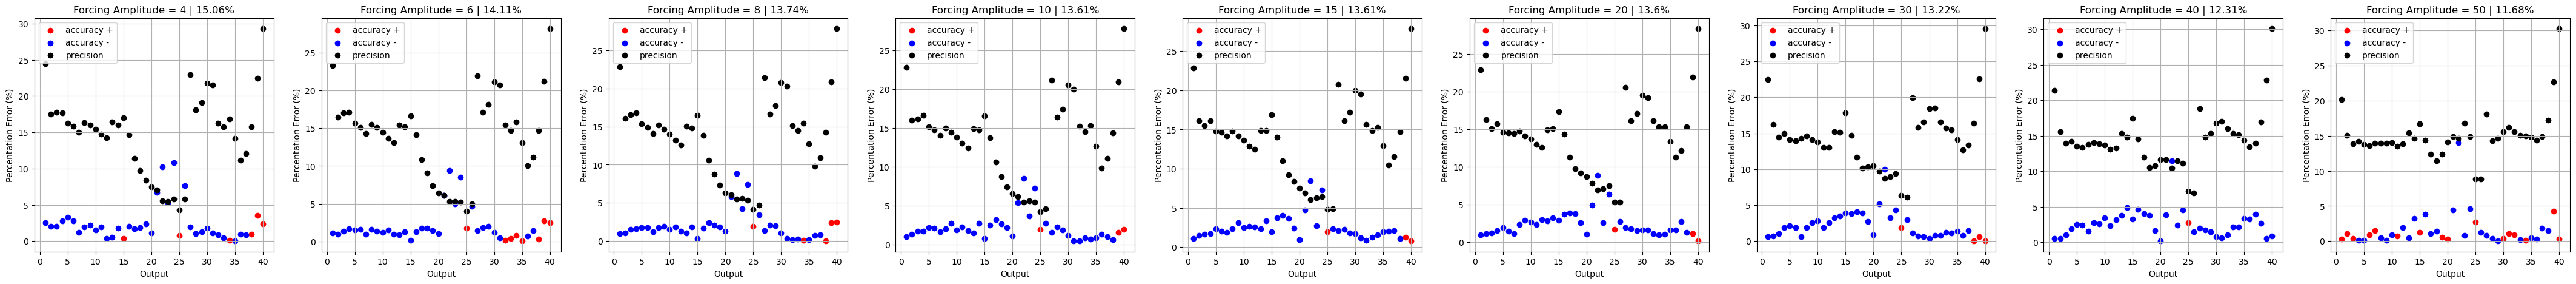

tensor([0.0681, 0.0668, 0.0567, 0.0576, 0.0586, 0.0582, 0.0574, 0.0582, 0.0565,
        0.0569, 0.0593, 0.0602, 0.0608, 0.0617, 0.0623, 0.0659, 0.0633, 0.0631,
        0.0716, 0.0746, 0.0692, 0.0705, 0.0683, 0.0679, 0.0796, 0.0854, 0.0717,
        0.0821, 0.0902, 0.0751])


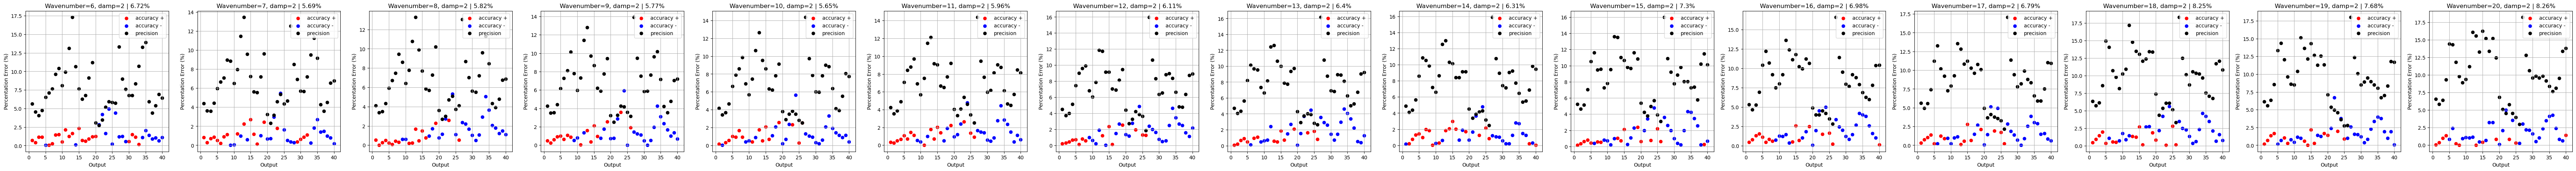

In [7]:
# rand
if n_rand_exp > 0:
    pred_rand = model.pred_rand.cpu() # ntime, nexp, 40
    diff_rand = pred_rand - targets_valid_rand[:,:,:]
    bias_rand = torch.mean(diff_rand[:, :, :], axis=0) / torch.std(targets_valid_rand[:,:,:], axis=0)
    prec_rand = torch.std(diff_rand[:, :, :], axis=0) / torch.std(targets_valid_rand[:,:,:], axis=0)
    print(torch.sqrt(torch.mean(diff_rand[:, :, :]**2, axis=(0, 2))) / torch.std(targets_valid_rand[:, :, :], axis=(0, 2)))
    rmse_rand = torch.sqrt(torch.mean(diff_rand**2, axis=0)) / torch.std(targets_valid_rand[:, :, :], axis=0)
    bias_rand = torch.mean(diff_rand[:, :, :], axis=0) / torch.std(targets_valid_rand[:, :, :], axis=0)
    # group by amplitude
    bias_rand = (bias_rand[::2, :] + bias_rand[1::2, :]) / 2.
    prec_rand = (prec_rand[::2, :] + prec_rand[1::2, :]) / 2.
    
    fig, ax = plt.subplots(1, inputs_valid_rand.shape[1]//2, figsize=(6 * inputs_valid_rand.shape[1]//2, 5))
    accuracy_p = copy.deepcopy(bias_rand.numpy())
    accuracy_p[accuracy_p < 0] = np.nan
    accuracy_n = copy.deepcopy(bias_rand.numpy())
    accuracy_n[accuracy_n > 0] = np.nan
    accuracy_n *= -1.
    precision = copy.deepcopy(prec_rand.numpy())
    total = torch.mean(diff_rand[:, :, :] ** 2, axis=(0, 2)) / torch.var(targets_valid_rand[:,:,:], axis=(0, 2))
    total = np.sqrt(total.numpy())
    # group by amplitude
    total = (total[::2] + total[1::2]) / 2.
    amp_list = [4, 6, 8, 10, 15, 20, 30, 40, 50]
    for icase in range(inputs_valid_rand.shape[1]//2):
        ax[icase].scatter(np.arange(1, 41), accuracy_p[icase, :] * 100, c='r', label='accuracy +')
        ax[icase].scatter(np.arange(1, 41), accuracy_n[icase, :] * 100, c='b', label='accuracy -')
        ax[icase].scatter(np.arange(1, 41), precision[icase, :] * 100, c='k', label='precision')
        ax[icase].legend()
        ax[icase].grid()
        ax[icase].set_xlabel('Output')
        ax[icase].set_ylabel('Percentation Error (%)')
        ax[icase].set_title(f'Forcing Amplitude = {amp_list[icase]} | {round(total[icase]*100, 2)}%')

    plt.show()

# wave
if n_wave_exp > 0:
    pred_wave = model.pred_wave.cpu()
    diff_wave = pred_wave - targets_valid_wave[:,:,:]
    bias_wave = torch.mean(diff_wave[:, :, :], axis=0) / torch.std(targets_valid_wave[:,:,:], axis=0)
    prec_wave = torch.std(diff_wave[:, :, :], axis=0) / torch.std(targets_valid_wave[:,:,:], axis=0)
    print(torch.sqrt(torch.mean(diff_wave[:, :, :]**2, axis=(0, 2))) / torch.std(targets_valid_wave[:, :, :], axis=(0, 2)))
    rmse_wave = torch.sqrt(torch.mean(diff_wave**2, axis=0)) / torch.std(targets_valid_wave[:, :, :], axis=0)
    bias_wave = torch.mean(diff_wave[:, :, :], axis=0) / torch.std(targets_valid_wave[:, :, :], axis=0)
    # group by wavenumber
    bias_wave = (bias_wave[::2, :] + bias_wave[1::2, :]) / 2.
    prec_wave = (prec_wave[::2, :] + prec_wave[1::2, :]) / 2.

    fig, ax = plt.subplots(1, inputs_valid_wave.shape[1]//2, figsize=(6 * inputs_valid_wave.shape[1]//2, 5))
    accuracy_p = copy.deepcopy(bias_wave.numpy())
    accuracy_p[accuracy_p < 0] = np.nan
    accuracy_n = copy.deepcopy(bias_wave.numpy())
    accuracy_n[accuracy_n > 0] = np.nan
    accuracy_n *= -1.
    precision = copy.deepcopy(prec_wave.numpy())
    total = torch.mean(diff_wave[192:, :, :] ** 2, axis=(0, 2)) / torch.var(targets_valid_wave[192:,:,:], axis=(0, 2))
    total = np.sqrt(total.numpy())
    # group by wavenumber
    total = (total[::2] + total[1::2]) / 2.
    wn_list = list(np.arange(6, 21))
    for icase in range(inputs_valid_wave.shape[1]//2):
        ax[icase].scatter(np.arange(1, 41), accuracy_p[icase, :] * 100, c='r', label='accuracy +')
        ax[icase].scatter(np.arange(1, 41), accuracy_n[icase, :] * 100, c='b', label='accuracy -')
        ax[icase].scatter(np.arange(1, 41), precision[icase, :] * 100, c='k', label='precision')
        ax[icase].legend()
        ax[icase].grid()
        ax[icase].set_xlabel('Output')
        ax[icase].set_ylabel('Percentation Error (%)')
        ax[icase].set_title(f'Wavenumber={wn_list[icase]}, damp=2 | {round(total[icase]*100, 2)}%')

    plt.show()

In [8]:
print((torch.sqrt(torch.mean(diff_rand[:, :, :]**2, axis=(0))) / torch.std(targets_valid_rand[:, :, :], axis=(0))).mean())
print(((abs(torch.mean(diff_rand[:, :, :], axis=(0)))) / torch.std(targets_valid_rand[:, :, :], axis=(0))).mean())

tensor(0.1466)
tensor(0.0216)


In [9]:
print((torch.sqrt(torch.mean(diff_wave[:, :, :]**2, axis=(0))) / torch.std(targets_valid_wave[:, :, :], axis=(0))).mean())
print(((abs(torch.mean(diff_wave[:, :, :], axis=(0)))) / torch.std(targets_valid_wave[:, :, :], axis=(0))).mean())

tensor(0.0820)
tensor(0.0151)


In [10]:
# add nan for precipitation since not predicted here
addnan = lambda x: torch.cat([x, x.new_full((x.size(0), 1), float('nan'))], dim=1)
rmse_rand = addnan(rmse_rand)
rmse_wave = addnan(rmse_wave)
bias_rand = addnan(bias_rand)
bias_wave = addnan(bias_wave)

### Percentage RMSE

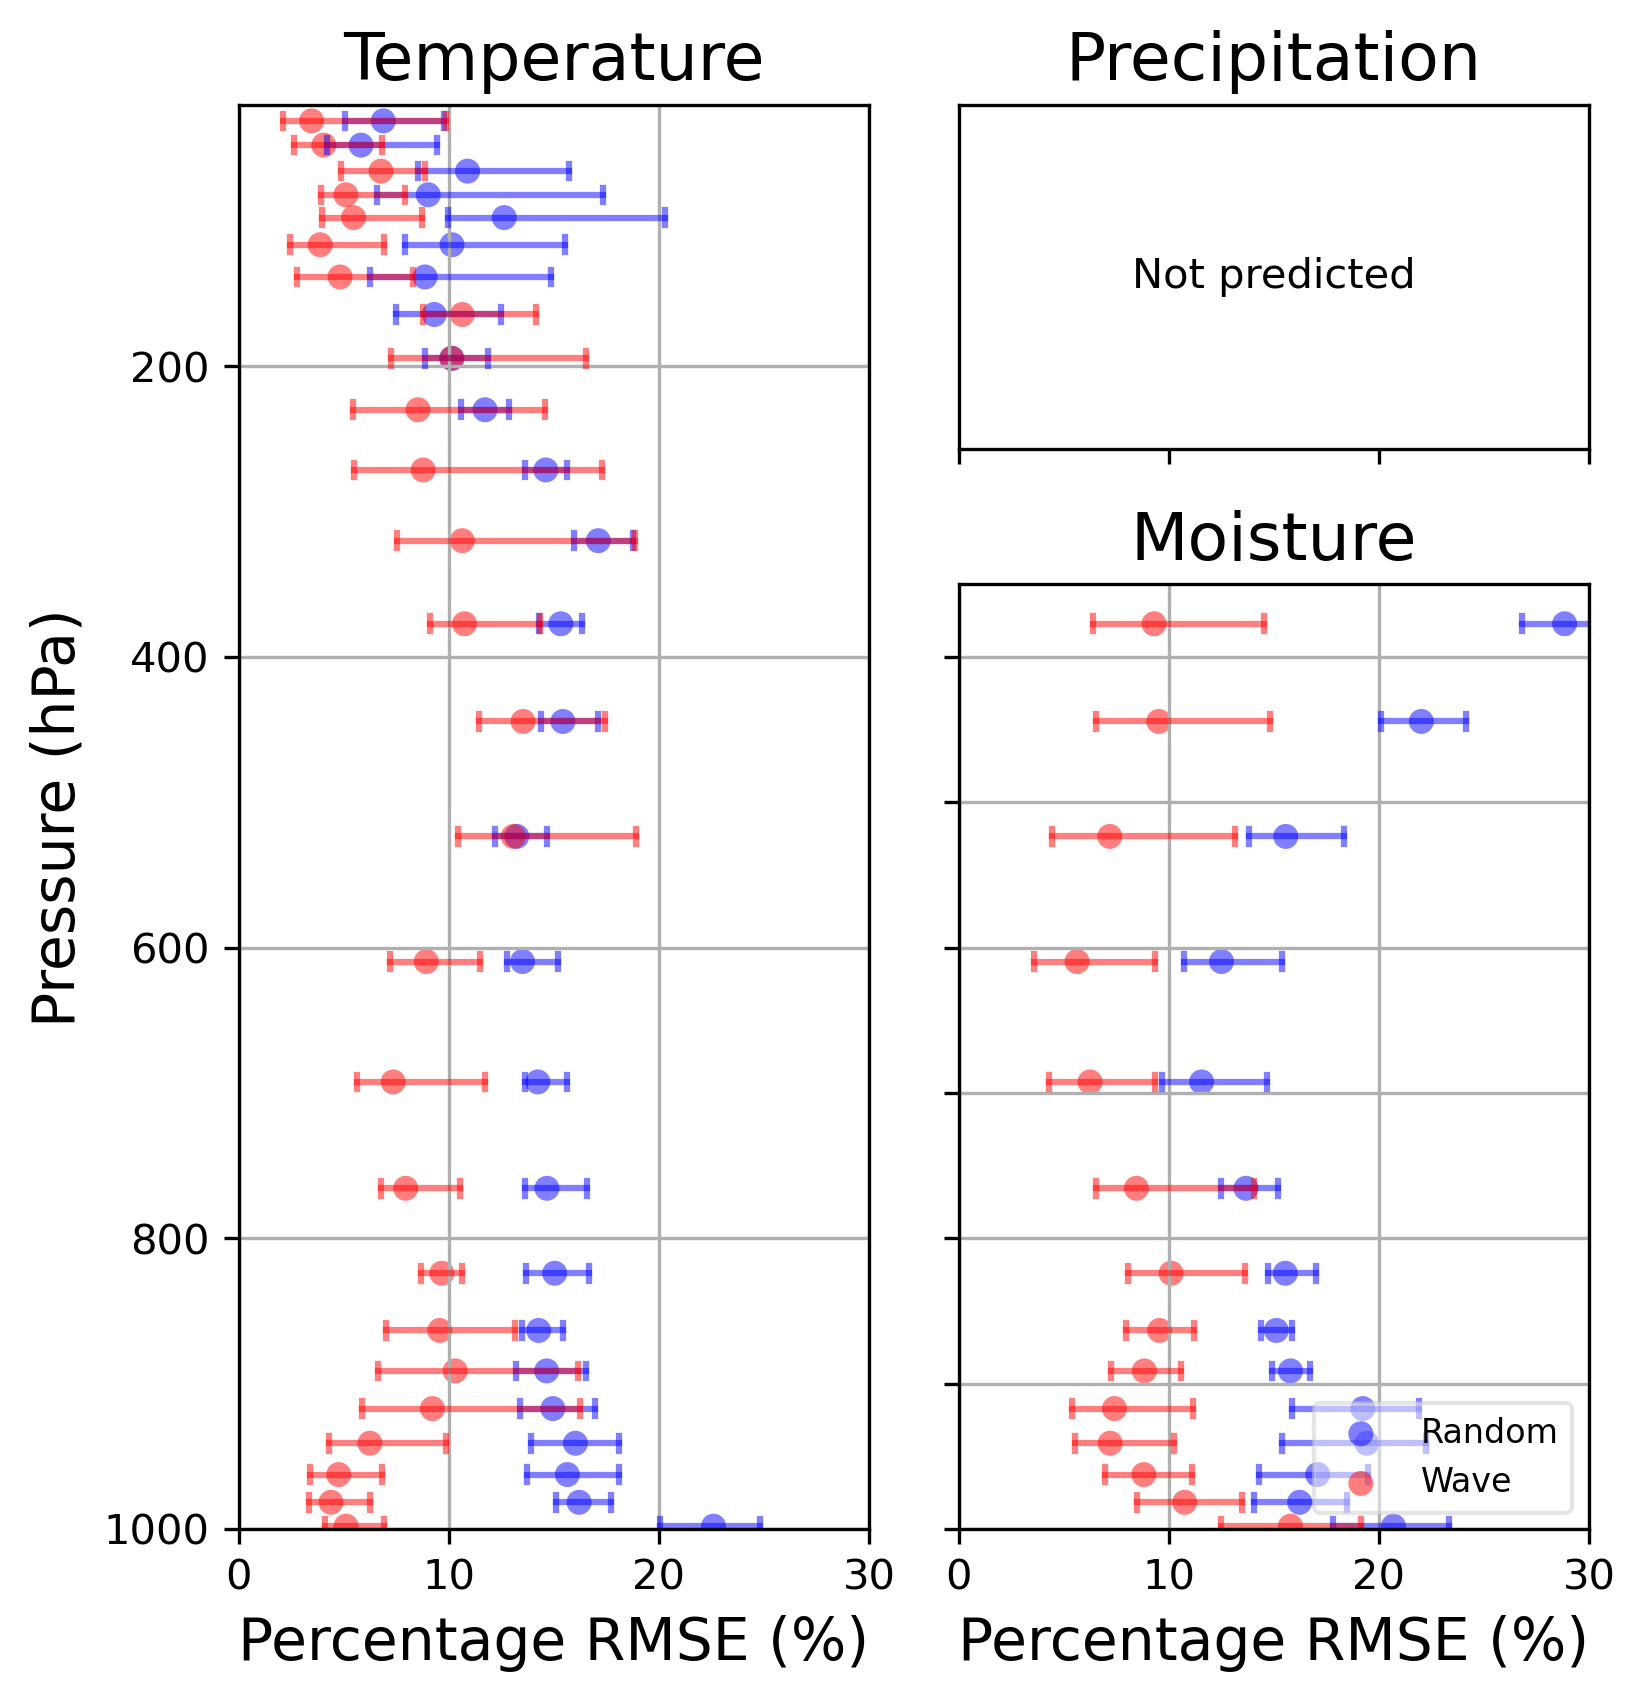

In [11]:
nc_file = '../data/RCE_randmultsine_spinup_256_0_3.nc'
data = nc.Dataset(nc_file)
p = data.variables['p'][:]
pres = p.squeeze()
fig = plt.figure(figsize=(6, 6), dpi=300)
ax1 = plt.axes([0.125, 0.1, 0.35, 0.98*0.85*0.95])
ax2 = plt.axes([0.525, 0.1, 0.35, 0.65*0.85*0.95])
ax3 = plt.axes([0.525, 0.7, 0.35, 0.1+0.98*0.85*0.95-0.7])
for i in range(26):
    ax1.plot([torch.min(100*rmse_rand[:, i]), torch.max(100*rmse_rand[:, i])], [pres[i], pres[i]], color='b', alpha=0.5)
    ax1.plot([torch.min(100*rmse_rand[:, i]), torch.min(100*rmse_rand[:, i])], [pres[i]-5, pres[i]+5], color='b', alpha=0.5)
    ax1.plot([torch.max(100*rmse_rand[:, i]), torch.max(100*rmse_rand[:, i])], [pres[i]-5, pres[i]+5], color='b', alpha=0.5)
    line1 = ax1.scatter([torch.mean(100*rmse_rand[:, i])], [pres[i]], color='b', alpha=0.5, edgecolor='none')
    ax1.plot([torch.min(100*rmse_wave[:, i]), torch.max(100*rmse_wave[:, i])], [pres[i], pres[i]], color='r', alpha=0.5)
    ax1.plot([torch.min(100*rmse_wave[:, i]), torch.min(100*rmse_wave[:, i])], [pres[i]-5, pres[i]+5], color='r', alpha=0.5)
    ax1.plot([torch.max(100*rmse_wave[:, i]), torch.max(100*rmse_wave[:, i])], [pres[i]-5, pres[i]+5], color='r', alpha=0.5)
    line2 = ax1.scatter([torch.mean(100*rmse_wave[:, i])], [pres[i]], color='r', alpha=0.5, edgecolor='none')
for i in range(14):
    ax2.plot([torch.min(100*rmse_rand[:, i+26]), torch.max(100*rmse_rand[:, i+26])], [pres[i], pres[i]], color='b', alpha=0.5)
    ax2.plot([torch.min(100*rmse_rand[:, i+26]), torch.min(100*rmse_rand[:, i+26])], [pres[i]-5, pres[i]+5], color='b', alpha=0.5)
    ax2.plot([torch.max(100*rmse_rand[:, i+26]), torch.max(100*rmse_rand[:, i+26])], [pres[i]-5, pres[i]+5], color='b', alpha=0.5)
    ax2.scatter([torch.mean(100*rmse_rand[:, i+26])], [pres[i]], color='b', alpha=0.5, edgecolor='none')
    ax2.plot([torch.min(100*rmse_wave[:, i+26]), torch.max(100*rmse_wave[:, i+26])], [pres[i], pres[i]], color='r', alpha=0.5)
    ax2.plot([torch.min(100*rmse_wave[:, i+26]), torch.min(100*rmse_wave[:, i+26])], [pres[i]-5, pres[i]+5], color='r', alpha=0.5)
    ax2.plot([torch.max(100*rmse_wave[:, i+26]), torch.max(100*rmse_wave[:, i+26])], [pres[i]-5, pres[i]+5], color='r', alpha=0.5)
    ax2.scatter([torch.mean(100*rmse_wave[:, i+26])], [pres[i]], color='r', alpha=0.5, edgecolor='none')
ax3.plot([torch.min(100*rmse_rand[:, 40]), torch.max(100*rmse_rand[:, 40])], [141.6, 141.6], color='b', alpha=0.5)
ax3.plot([torch.min(100*rmse_rand[:, 40]), torch.min(100*rmse_rand[:, 40])], [136.6, 146.6], color='b', alpha=0.5)
ax3.plot([torch.max(100*rmse_rand[:, 40]), torch.max(100*rmse_rand[:, 40])], [136.6, 146.6], color='b', alpha=0.5)
ax3.scatter(torch.mean(100*rmse_rand[:, 40]), 141.6, color='b', alpha=0.5, edgecolor='none')
ax3.plot([torch.min(100*rmse_wave[:, 40]), torch.max(100*rmse_wave[:, 40])], [141.6, 141.6], color='r', alpha=0.5)
ax3.plot([torch.min(100*rmse_wave[:, 40]), torch.min(100*rmse_wave[:, 40])], [136.6, 146.6], color='r', alpha=0.5)
ax3.plot([torch.max(100*rmse_wave[:, 40]), torch.max(100*rmse_wave[:, 40])], [136.6, 146.6], color='r', alpha=0.5)
ax3.scatter(torch.mean(100*rmse_wave[:, 40]), 141.6, color='r', alpha=0.5, edgecolor='none')
#ax2.scatter(100*rmse_mean[26:40], pres[:14], color='k', edgecolor='none')
#ax3.scatter(100*rmse_mean[40], 1, color='k', edgecolor='none')
ax2.legend([line1, line2], ['Random', 'Wave'], loc='lower right', fontsize=8, framealpha=0.5)
ax1.set_ylim(1000, 20)
ax2.set_ylim(1000, 350)
ax3.set_ylim(263.2, 20)
ax2.set_yticklabels([])
ax3.set_yticks([])
ax3.set_yticklabels([])
ax3.set_xticklabels([])
ax1.set_xlim(0, 30)
ax2.set_xlim(0, 30)
ax3.set_xlim(0, 30)
ax1.grid()
ax2.grid()
#ax3.grid()
ax3.text(
    0.5, 0.5,           # x, y in axes‐fraction (0 = left/bottom, 1 = right/top)
    "Not predicted",   # your text
    transform=ax3.transAxes,  # interpret (x, y) in axes coordinate system
    ha="center",        # horizontal alignment
    va="center",        # vertical alignment
    fontsize=10,        # optional styling
)
ax1.set_title('Temperature', fontsize=16)
ax2.set_title('Moisture', fontsize=16)
ax3.set_title('Precipitation', fontsize=16)
ax1.set_ylabel('Pressure (hPa)', fontsize=14)
ax1.set_xlabel('Percentage RMSE (%)', fontsize=14)
ax2.set_xlabel('Percentage RMSE (%)', fontsize=14)
plt.show()

### Percentage Bias

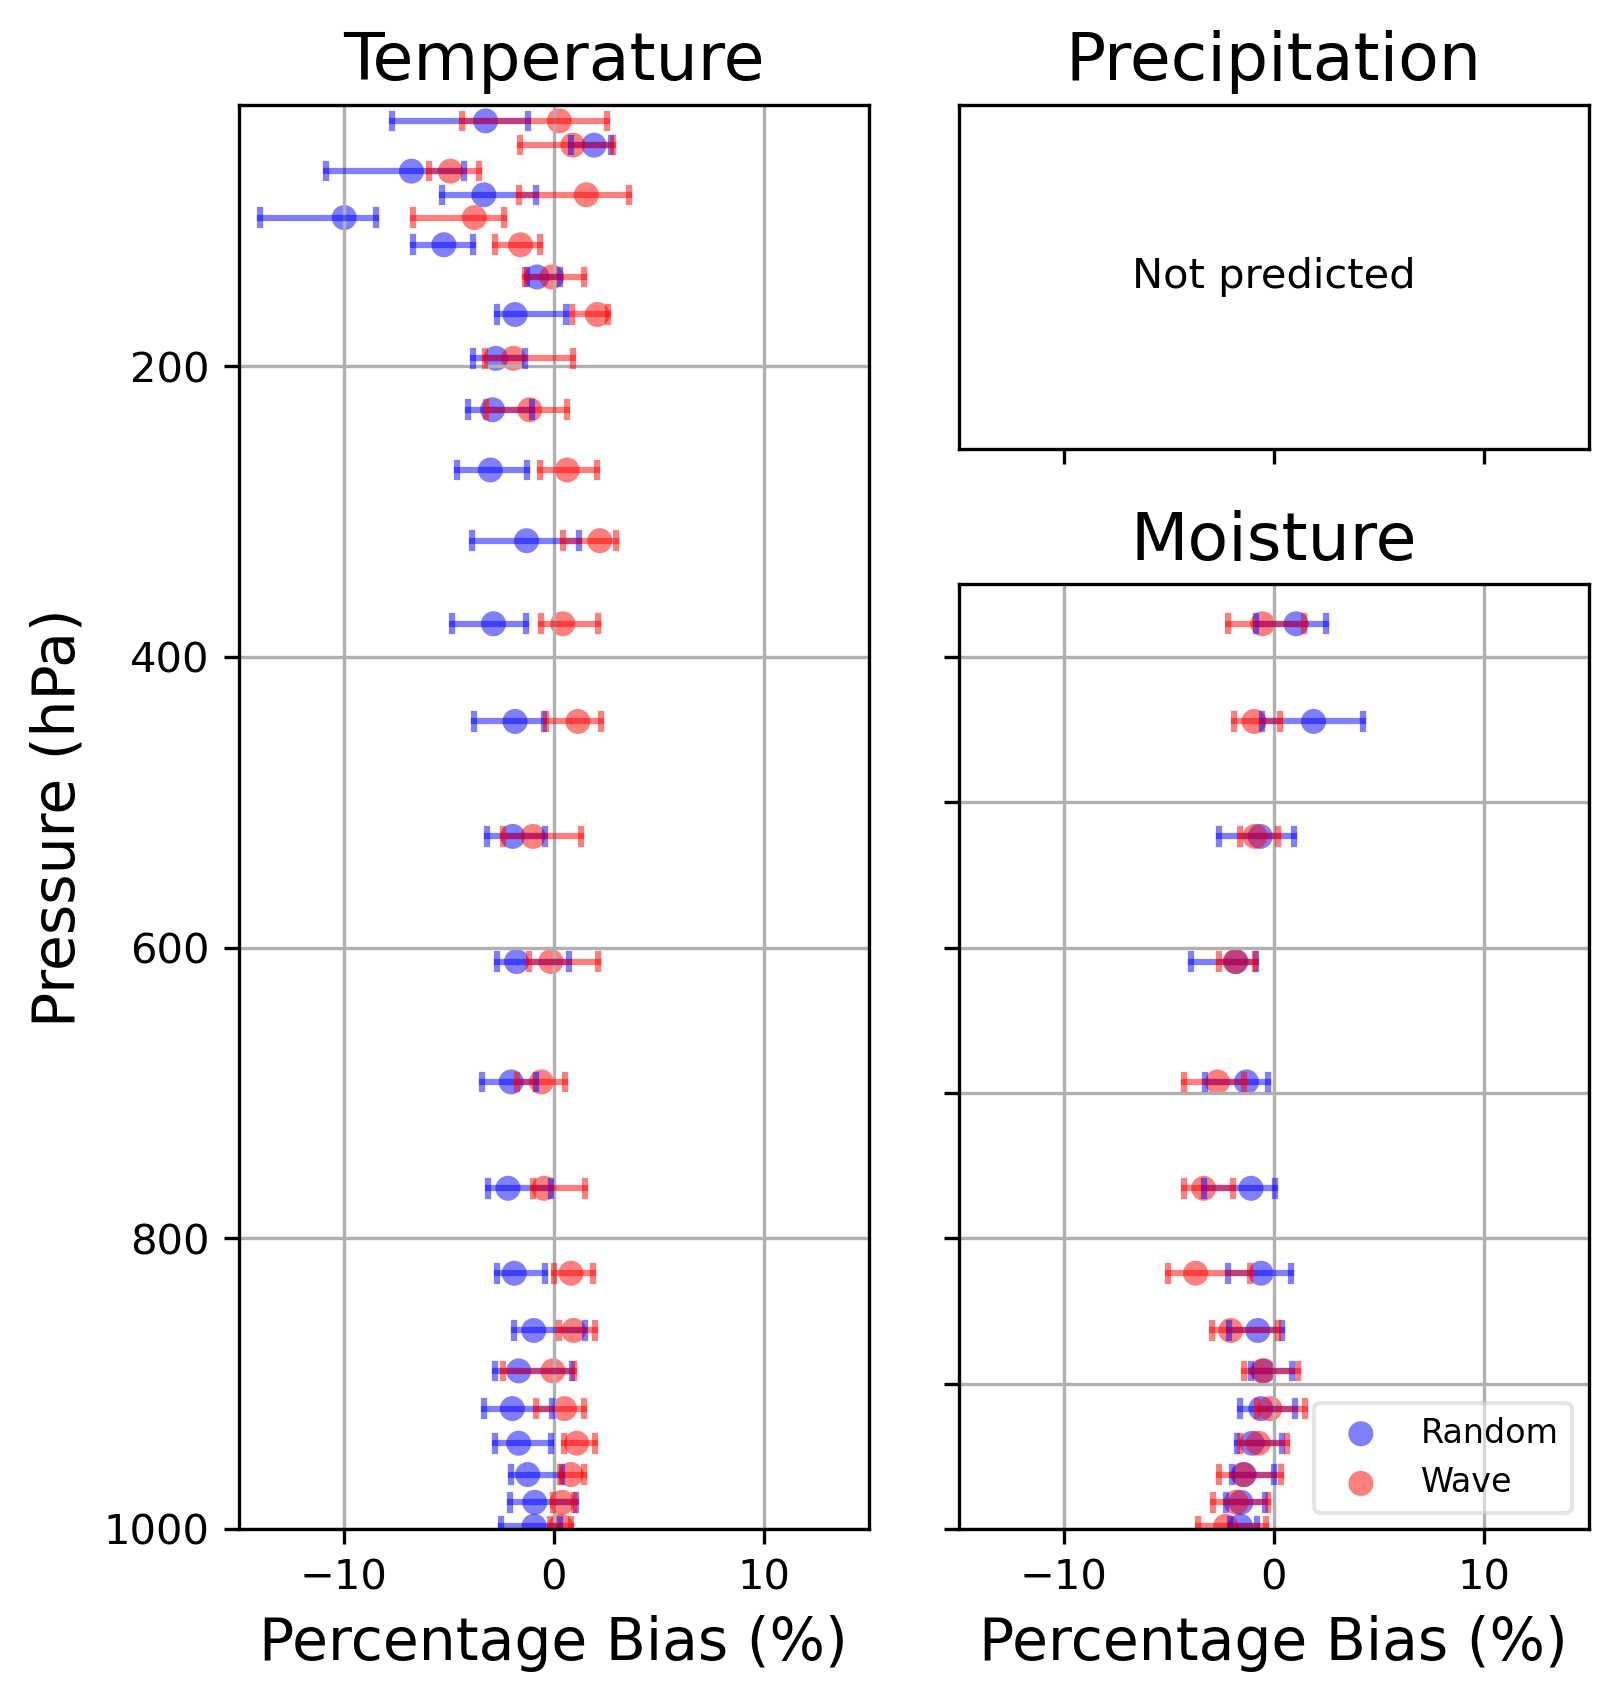

In [12]:
nc_file = '../data/RCE_randmultsine_spinup_256_0_3.nc'
data = nc.Dataset(nc_file)
p = data.variables['p'][:]
pres = p.squeeze()
fig = plt.figure(figsize=(6, 6), dpi=300)
ax1 = plt.axes([0.125, 0.1, 0.35, 0.98*0.85*0.95])
ax2 = plt.axes([0.525, 0.1, 0.35, 0.65*0.85*0.95])
ax3 = plt.axes([0.525, 0.7, 0.35, 0.1+0.98*0.85*0.95-0.7])
for i in range(26):
    ax1.plot([torch.min(100*bias_rand[:, i]), torch.max(100*bias_rand[:, i])], [pres[i], pres[i]], color='b', alpha=0.5)
    ax1.plot([torch.min(100*bias_rand[:, i]), torch.min(100*bias_rand[:, i])], [pres[i]-5, pres[i]+5], color='b', alpha=0.5)
    ax1.plot([torch.max(100*bias_rand[:, i]), torch.max(100*bias_rand[:, i])], [pres[i]-5, pres[i]+5], color='b', alpha=0.5)
    line1 = ax1.scatter([torch.mean(100*bias_rand[:, i])], [pres[i]], color='b', alpha=0.5, edgecolor='none')
    ax1.plot([torch.min(100*bias_wave[:, i]), torch.max(100*bias_wave[:, i])], [pres[i], pres[i]], color='r', alpha=0.5)
    ax1.plot([torch.min(100*bias_wave[:, i]), torch.min(100*bias_wave[:, i])], [pres[i]-5, pres[i]+5], color='r', alpha=0.5)
    ax1.plot([torch.max(100*bias_wave[:, i]), torch.max(100*bias_wave[:, i])], [pres[i]-5, pres[i]+5], color='r', alpha=0.5)
    line2 = ax1.scatter([torch.mean(100*bias_wave[:, i])], [pres[i]], color='r', alpha=0.5, edgecolor='none')
for i in range(14):
    ax2.plot([torch.min(100*bias_rand[:, i+26]), torch.max(100*bias_rand[:, i+26])], [pres[i], pres[i]], color='b', alpha=0.5)
    ax2.plot([torch.min(100*bias_rand[:, i+26]), torch.min(100*bias_rand[:, i+26])], [pres[i]-5, pres[i]+5], color='b', alpha=0.5)
    ax2.plot([torch.max(100*bias_rand[:, i+26]), torch.max(100*bias_rand[:, i+26])], [pres[i]-5, pres[i]+5], color='b', alpha=0.5)
    ax2.scatter([torch.mean(100*bias_rand[:, i+26])], [pres[i]], color='b', alpha=0.5, edgecolor='none')
    ax2.plot([torch.min(100*bias_wave[:, i+26]), torch.max(100*bias_wave[:, i+26])], [pres[i], pres[i]], color='r', alpha=0.5)
    ax2.plot([torch.min(100*bias_wave[:, i+26]), torch.min(100*bias_wave[:, i+26])], [pres[i]-5, pres[i]+5], color='r', alpha=0.5)
    ax2.plot([torch.max(100*bias_wave[:, i+26]), torch.max(100*bias_wave[:, i+26])], [pres[i]-5, pres[i]+5], color='r', alpha=0.5)
    ax2.scatter([torch.mean(100*bias_wave[:, i+26])], [pres[i]], color='r', alpha=0.5, edgecolor='none')
ax3.plot([torch.min(100*bias_rand[:, 40]), torch.max(100*bias_rand[:, 40])], [141.6, 141.6], color='b', alpha=0.5)
ax3.plot([torch.min(100*bias_rand[:, 40]), torch.min(100*bias_rand[:, 40])], [136.6, 146.6], color='b', alpha=0.5)
ax3.plot([torch.max(100*bias_rand[:, 40]), torch.max(100*bias_rand[:, 40])], [136.6, 146.6], color='b', alpha=0.5)
ax3.scatter(torch.mean(100*bias_rand[:, 40]), 141.6, color='b', alpha=0.5, edgecolor='none')
ax3.plot([torch.min(100*bias_wave[:, 40]), torch.max(100*bias_wave[:, 40])], [141.6, 141.6], color='r', alpha=0.5)
ax3.plot([torch.min(100*bias_wave[:, 40]), torch.min(100*bias_wave[:, 40])], [136.6, 146.6], color='r', alpha=0.5)
ax3.plot([torch.max(100*bias_wave[:, 40]), torch.max(100*bias_wave[:, 40])], [136.6, 146.6], color='r', alpha=0.5)
ax3.scatter(torch.mean(100*bias_wave[:, 40]), 141.6, color='r', alpha=0.5, edgecolor='none')
#line3 = ax1.scatter(100*bias_mean[:26], pres[:26], color='k', edgecolor='none')
#ax2.scatter(100*bias_mean[26:40], pres[:14], color='k', edgecolor='none')
#ax3.scatter(100*bias_mean[40], 1, color='k', edgecolor='none')
ax2.legend([line1, line2], ['Random', 'Wave'], loc='lower right', fontsize=8, framealpha=0.5)
ax1.set_ylim(1000, 20)
ax2.set_ylim(1000, 350)
ax3.set_ylim(263.2, 20)
ax2.set_yticklabels([])
ax3.set_yticks([])
ax3.set_yticklabels([])
ax3.set_xticklabels([])
ax1.set_xlim(-15, 15)
ax2.set_xlim(-15, 15)
ax3.set_xlim(-15, 15)
ax1.grid()
ax2.grid()
#ax3.grid()
ax3.text(
    0.5, 0.5,           # x, y in axes‐fraction (0 = left/bottom, 1 = right/top)
    "Not predicted",   # your text
    transform=ax3.transAxes,  # interpret (x, y) in axes coordinate system
    ha="center",        # horizontal alignment
    va="center",        # vertical alignment
    fontsize=10,        # optional styling
)
ax1.set_title('Temperature', fontsize=16)
ax2.set_title('Moisture', fontsize=16)
ax3.set_title('Precipitation', fontsize=16)
ax1.set_ylabel('Pressure (hPa)', fontsize=14)
ax1.set_xlabel('Percentage Bias (%)', fontsize=14)
ax2.set_xlabel('Percentage Bias (%)', fontsize=14)
plt.show()